In [203]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import special as sp
from scipy import optimize as opt
import seaborn as sns

In [279]:
def g(t):
    return np.log(1+t)

def h(t):
    return sp.erf((t+1)/5)

In [280]:
BASE_PRECISION = 0.1
CONST = BASE_PRECISION/(1-BASE_PRECISION)

RECALL_H = 0.3
PRECISION_H = 0.4

def precision(t):
    n_t = (g(t) - g(0))/(g(1)-g(0))
    return (n_t + CONST)/(1 + CONST)

def recall(t):
    return 1 - (h(t) - h(0)) / (h(1)-h(0))

def outcome(t, alpha):
    recall_ratio = recall(t)/RECALL_H
    prec_ratio = precision(t)/PRECISION_H
    
    return (recall_ratio/prec_ratio) * (prec_ratio - alpha)/(1 - alpha)

def max_outcome(alpha):
    return opt.fminbound(lambda t: -outcome(t, alpha), 0, 1)

Text(0, 0.5, 'Optimal threshold')

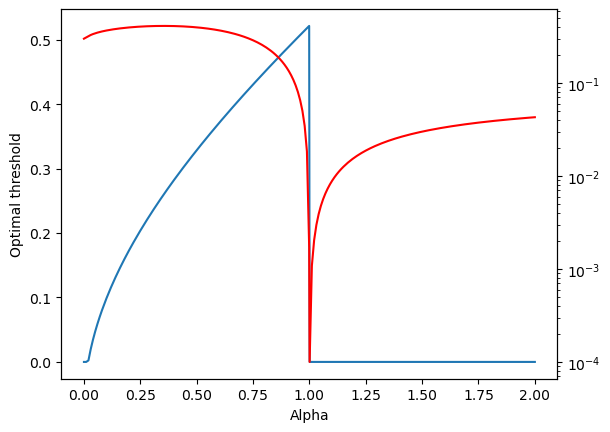

In [281]:
fig, ax = plt.subplots()
tax = ax.twinx()
tax.set_yscale("log")
alphas = np.r_[ #np.linspace(0, 0.999, 101)
    np.linspace(0, 0.999, 101), 
    np.linspace(1.001, 2, 101)
]
max_thresh = [max_outcome(alpha) for alpha in alphas]
max_outcom = [1/outcome(t, alpha) for (t, alpha) in zip(max_thresh, alphas)]
ax.plot(alphas, max_thresh)
tax.plot(alphas, max_outcom, color="red")
ax.set_xlabel("Alpha")
ax.set_ylabel("Optimal threshold")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


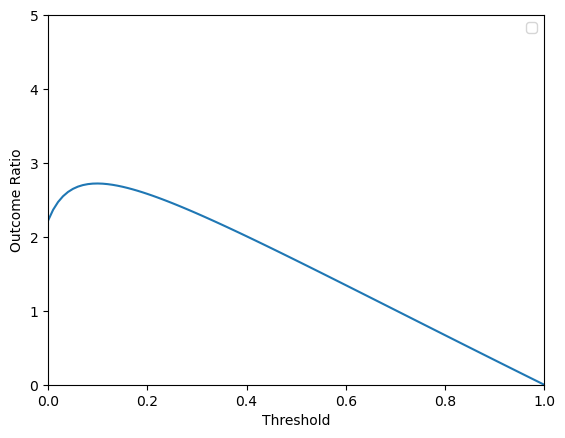

In [282]:
fig, ax = plt.subplots()

ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
ax.plot(thresh, outcome(thresh, 0.1))
ax.set_xlabel("Threshold")
ax.set_ylabel("Outcome Ratio")
ax.legend()

In [277]:
thresh = np.linspace(0, 1, 101)

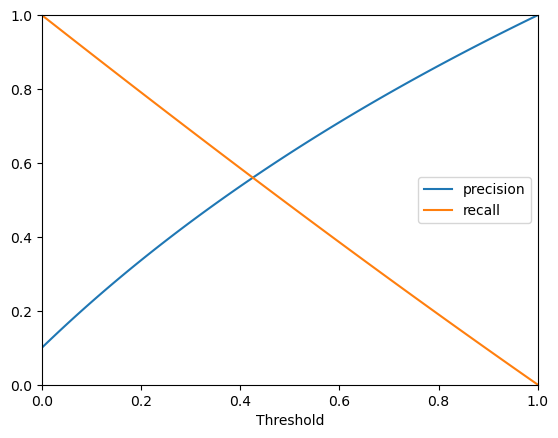

In [284]:
fig, ax = plt.subplots()

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.plot(thresh, precision(thresh), label="precision")
ax.plot(thresh, recall(thresh), label="recall")
ax.set_xlabel("Threshold")
ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


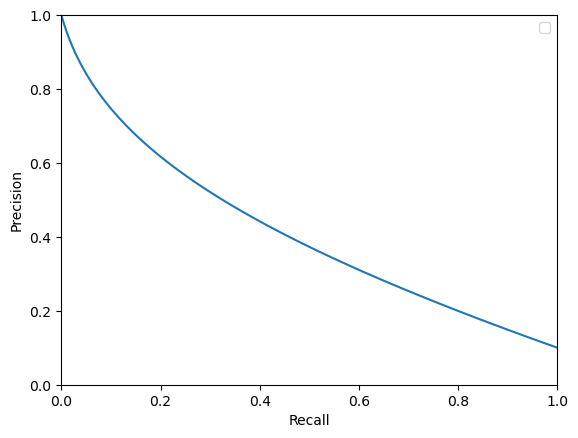

In [263]:
fig, ax = plt.subplots()

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.plot(recall(thresh), precision(thresh))
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

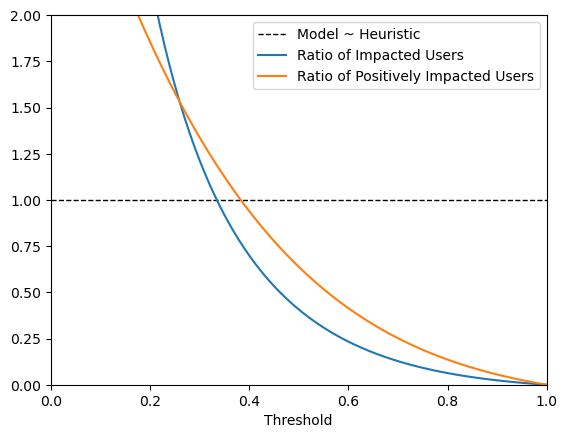

In [272]:
fig, ax = plt.subplots()

prec_ratio = precision(thresh)/PRECISION_H
rec_ratio = recall(thresh)/RECALL_H
impacted = rec_ratio/prec_ratio

ax.set_xlim(0, 1)
ax.set_ylim(0, 2)
ax.axhline(1, color="black", ls="--", lw=1, label="Model ~ Heuristic")
ax.plot(thresh, impacted, label="Ratio of Impacted Users")
ax.plot(thresh, rec_ratio, label="Ratio of Positively Impacted Users")

ax.set_xlabel("Threshold")
ax.legend()